# Data Understanding

## Import Library

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from collections import Counter
import re
import warnings
import os

warnings.filterwarnings('ignore')

# Konfigurasi tampilan plot
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

os.makedirs('output_eda', exist_ok=True)
print('Library berhasil diimpor!')

Library berhasil diimpor!


## Load Dataset

In [25]:
df = pd.read_csv('ulasan.csv')
print(f'Dataset berhasil dimuat: {df.shape[0]} baris x {df.shape[1]} kolom')
df.head(10)

Dataset berhasil dimuat: 499 baris x 6 kolom


,No,Username,Rating,Waktu,Ulasan Text,Variasi
0,1,t*****a,5,2022-08-28 16:48,Kualitas: bagus Cocok Untuk: boluu Nyampenya c...,-
1,2,t*****9,5,2022-03-17 19:32,Jenis: tepung ketan hitam Harga: murah Kualita...,-
2,3,a*****2,5,2025-07-07 20:01,Rasa: enak Tekstur: normal seperti tepung keta...,-
3,4,nienieng,5,2025-06-06 19:08,Rasa: enak dibuat bolu Kegunaan: buat bolu ket...,-
4,5,Langganan,5,2022-02-05 10:19,Jenis: tepung ketan hitam Harga: murah Kualita...,-
5,6,m*****3,5,2023-06-09 08:42,"Kualitas: sangat baikkk sekali, enak poll dan ...",-
6,7,Langganan,5,2022-02-02 12:40,Jenis: Tepung ketan hitam Harga: murah Kualita...,-
7,8,3ra43w69o0,5,2025-08-05 12:41,Rasa: enak banget Tekstur: lembut Kegunaan: co...,-
8,9,1,5,2022-06-06 17:15,Sudah dicoba buat bikin bolu ketan hitam dan e...,-
9,10,lianawatihasibuan582,5,2025-06-17 14:03,"Komposisinya 100% beras ketan hitam,alami dan ...",-


## Deskripsi Data (Describe Data)
### Informasi Umum Dataset

In [26]:
print('=== Informasi Tipe Data & Nilai Non-Null ===')
df.info()

=== Informasi Tipe Data & Nilai Non-Null ===
<class 'pandas.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   No           499 non-null    int64
 1   Username     499 non-null    str  
 2   Rating       499 non-null    int64
 3   Waktu        499 non-null    str  
 4   Ulasan Text  499 non-null    str  
 5   Variasi      499 non-null    str  
dtypes: int64(2), str(4)
memory usage: 23.5 KB


### Statistik Deskriptif

In [27]:
df.describe()

,No,Rating
count,499.000000,499.000000
mean,250.000000,4.995992
std,144.193157,0.089532
min,1.000000,3.000000
25%,125.500000,5.000000
50%,250.000000,5.000000
75%,374.500000,5.000000
max,499.000000,5.000000


### Kolom yang Tersedia

In [28]:
print('Kolom dalam dataset:')
for i, col in enumerate(df.columns, 1):
    dtype = df[col].dtype
    unique = df[col].nunique()
    print(f'  {i}. {col:<15} | dtype: {str(dtype):<10} | unique values: {unique}')

Kolom dalam dataset:
  1. No              | dtype: int64      | unique values: 499
  2. Username        | dtype: str        | unique values: 394
  3. Rating          | dtype: int64      | unique values: 2
  4. Waktu           | dtype: str        | unique values: 490
  5. Ulasan Text     | dtype: str        | unique values: 493
  6. Variasi         | dtype: str        | unique values: 1


---
## Verifikasi Kualitas Data (Verify Data Quality)
### Missing Values (Nilai Kosong)

Missing Values per Kolom:
             Jumlah Kosong  Persentase (%)
No                       0             0.0
Username                 0             0.0
Rating                   0             0.0
Waktu                    0             0.0
Ulasan Text              0             0.0
Variasi                  0             0.0


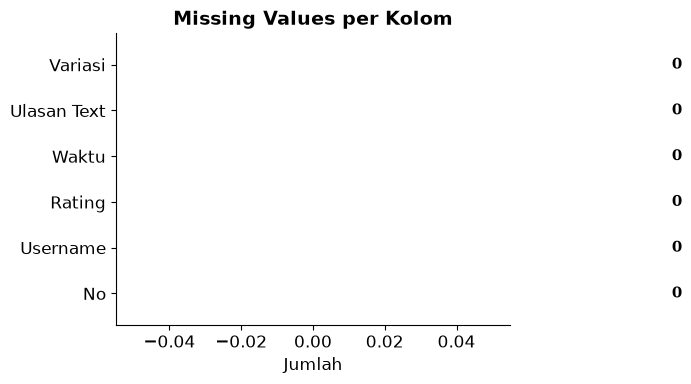


Total missing values: 0


In [29]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Jumlah Kosong': missing, 'Persentase (%)': missing_pct})
print('Missing Values per Kolom:')
print(missing_df)

# Visualisasi
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#EF5350' if v > 0 else '#66BB6A' for v in missing.values]
bars = ax.barh(missing.index, missing.values, color=colors, edgecolor='white')
for bar, val in zip(bars, missing.values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2.,
            f'{val}', va='center', fontsize=11, fontweight='bold')
ax.set_title('Missing Values per Kolom', fontsize=14, fontweight='bold')
ax.set_xlabel('Jumlah')
plt.tight_layout()
plt.show()
print(f'\nTotal missing values: {missing.sum()}')

### Data Duplikat

In [30]:
duplikat_semua  = df.duplicated().sum()
duplikat_teks   = df['Ulasan Text'].duplicated().sum()

print(f'Baris duplikat penuh   : {duplikat_semua} baris')
print(f'Ulasan Text duplikat   : {duplikat_teks} baris')

if duplikat_teks > 0:
    print('\nContoh baris yang terduplikasi:')
    dup_examples = df[df['Ulasan Text'].duplicated(keep=False)].sort_values('Ulasan Text')
    display(dup_examples[['No','Username','Waktu','Ulasan Text']].head(8))

Baris duplikat penuh   : 0 baris
Ulasan Text duplikat   : 6 baris

Contoh baris yang terduplikasi:


,No,Username,Waktu,Ulasan Text
103,104,wetriyputri,2025-08-30 22:02,"Desain sangat menanrik dan bagus, ukuran pas d..."
127,128,wetriyputri,2025-08-30 22:03,"Desain sangat menanrik dan bagus, ukuran pas d..."
123,124,franiko88,2025-09-14 02:11,Makasih shopee buat diskonnya jadi bisa beli b...
417,418,franiko88,2025-08-23 01:14,Makasih shopee buat diskonnya jadi bisa beli b...
269,270,leniprastyanii,2026-04-24 17:40,Tekstur: lembut Rasa: enak Alhamdulillah paket...
270,271,leniprastyanii,2026-03-06 18:38,Tekstur: lembut Rasa: enak Alhamdulillah paket...
328,329,leniprastyanii,2026-03-14 09:23,Tekstur: lembut Rasa: enak Alhamdulillah paket...
329,330,leniprastyanii,2026-03-12 16:14,Tekstur: lembut Rasa: enak Alhamdulillah paket...


### Distribusi Rating

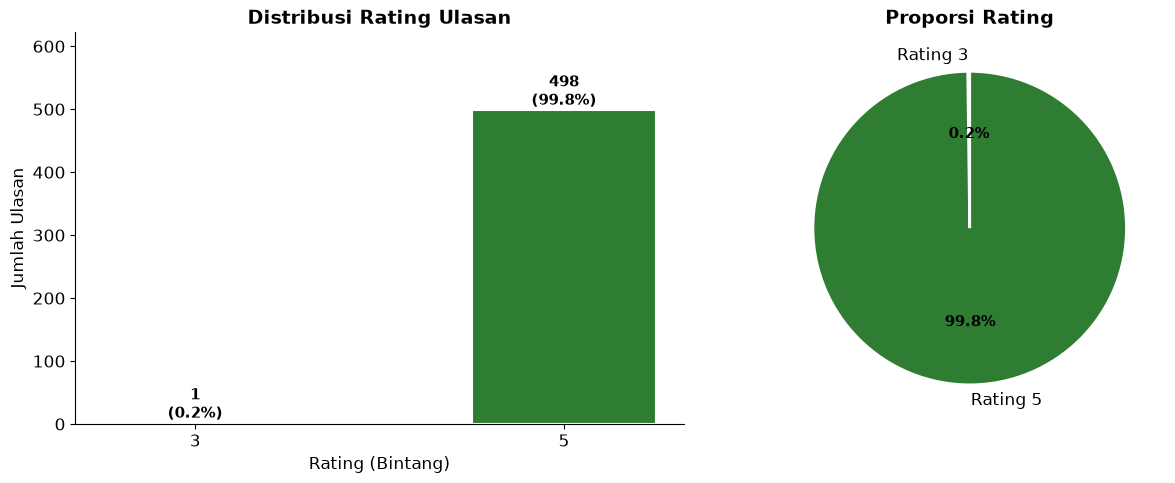

In [31]:
rating_counts = df['Rating'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar Chart
bar_colors = {1: '#E53935', 2: '#FB8C00', 3: '#FDD835', 4: '#7CB342', 5: '#2E7D32'}
colors_list = [bar_colors.get(r, '#90A4AE') for r in rating_counts.index]
bars = axes[0].bar(rating_counts.index.astype(str), rating_counts.values,
                   color=colors_list, edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, rating_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                 f'{val}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
axes[0].set_title('Distribusi Rating Ulasan', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rating (Bintang)')
axes[0].set_ylabel('Jumlah Ulasan')
axes[0].set_ylim(0, rating_counts.max() * 1.25)

# Pie Chart
pie_colors = [bar_colors.get(r, '#90A4AE') for r in rating_counts.index]
wedges, texts, autotexts = axes[1].pie(
    rating_counts.values,
    labels=[f'Rating {r}' for r in rating_counts.index],
    colors=pie_colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
axes[1].set_title('Proporsi Rating', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### Deteksi Noise dari Scraper

In [32]:
# Noise: sisa nomor halaman Shopee (e.g., "1 2 ... 5 6 7")
noise_pattern = r'\b\d+\s+\d+\s+\.\.\.'
df['has_noise'] = df['Ulasan Text'].astype(str).str.contains(noise_pattern, regex=True)
noise_count = df['has_noise'].sum()

# Ulasan sangat pendek
df['panjang_teks'] = df['Ulasan Text'].astype(str).apply(len)
terlalu_pendek = (df['panjang_teks'] < 10).sum()

print(f'Ulasan mengandung noise nomor halaman: {noise_count} baris ({noise_count/len(df)*100:.1f}%)')
print(f'Ulasan sangat pendek (< 10 karakter) : {terlalu_pendek} baris')

print('\nContoh ulasan dengan noise nomor halaman:')
display(df[df['has_noise']][['No','Username','Ulasan Text']].head(5))

Ulasan mengandung noise nomor halaman: 32 baris (6.4%)
Ulasan sangat pendek (< 10 karakter) : 4 baris

Contoh ulasan dengan noise nomor halaman:


,No,Username,Ulasan Text
5,6,m*****3,"Kualitas: sangat baikkk sekali, enak poll dan ..."
11,12,s*****u,Cocok Untuk: bolu ketan hitam Kualitas tepungn...
18,19,d*****a,Rasa: lezatt Tekstur: lembut Kegunaan: cocok u...
31,32,i*****y,Klo dilihat dari tekstur nya tepung ketannya k...
37,38,juhartiyah,Rasa: sangat enak khas beras hitam Tekstur: me...


### Username Anomali

In [33]:
anonymous_count = (df['Username'] == 'Anonymous').sum()
angka_only      = df['Username'].astype(str).str.match(r'^\d+$').sum()
langganan_count = (df['Username'] == 'Langganan').sum()

print('=== Pengecekan Username Anomali ===')
print(f"  Username 'Anonymous'       : {anonymous_count} baris")
print(f"  Username berupa angka saja : {angka_only} baris")
print(f"  Username 'Langganan'       : {langganan_count} baris (potensi duplikat scraping)")

# Top 10 username paling sering muncul
print('\nTop 10 Username Paling Sering Muncul:')
top_users = df['Username'].value_counts().head(10)
display(top_users.to_frame('Jumlah Ulasan'))

=== Pengecekan Username Anomali ===
  Username 'Anonymous'       : 3 baris
  Username berupa angka saja : 2 baris
  Username 'Langganan'       : 15 baris (potensi duplikat scraping)

Top 10 Username Paling Sering Muncul:


,Jumlah Ulasan
Username,
Langganan,15
leniprastyanii,7
a*****2,5
a*****i,5
dwiriy19,4
a*****a,4
r*****s,4
aw389d478a,4
d*****4,4


---
## Eksplorasi Data (Exploratory Data Analysis)
### Distribusi Panjang Teks Ulasan

=== Statistik Panjang Ulasan ===
  Rata-rata : 119 karakter
  Median    : 106 karakter
  Min       : 4 karakter
  Max       : 527 karakter


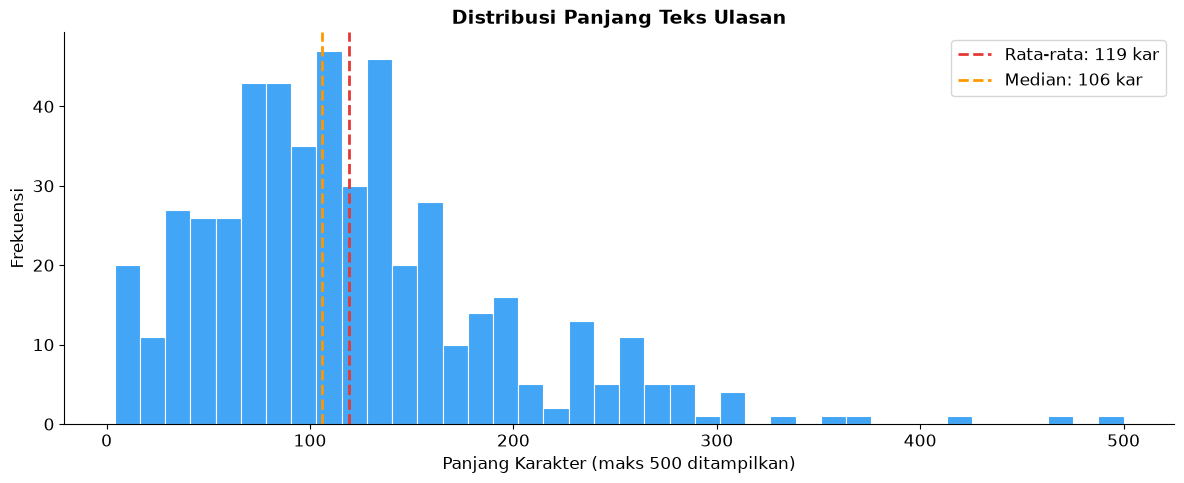

In [39]:
print('=== Statistik Panjang Ulasan ===')
print(f"  Rata-rata : {df['panjang_teks'].mean():.0f} karakter")
print(f"  Median    : {df['panjang_teks'].median():.0f} karakter")
print(f"  Min       : {df['panjang_teks'].min()} karakter")
print(f"  Max       : {df['panjang_teks'].max()} karakter")

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df['panjang_teks'].clip(upper=500), bins=40, color='#42A5F5', edgecolor='white', linewidth=0.8)
ax.axvline(df['panjang_teks'].mean(), color='#E53935', linestyle='--', linewidth=2,
           label=f"Rata-rata: {df['panjang_teks'].mean():.0f} kar")
ax.axvline(df['panjang_teks'].median(), color='#FF9800', linestyle='--', linewidth=2,
           label=f"Median: {df['panjang_teks'].median():.0f} kar")
ax.set_title('Distribusi Panjang Teks Ulasan', fontsize=14, fontweight='bold')
ax.set_xlabel('Panjang Karakter (maks 500 ditampilkan)')
ax.set_ylabel('Frekuensi')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

### Tren Jumlah Ulasan per Tahun

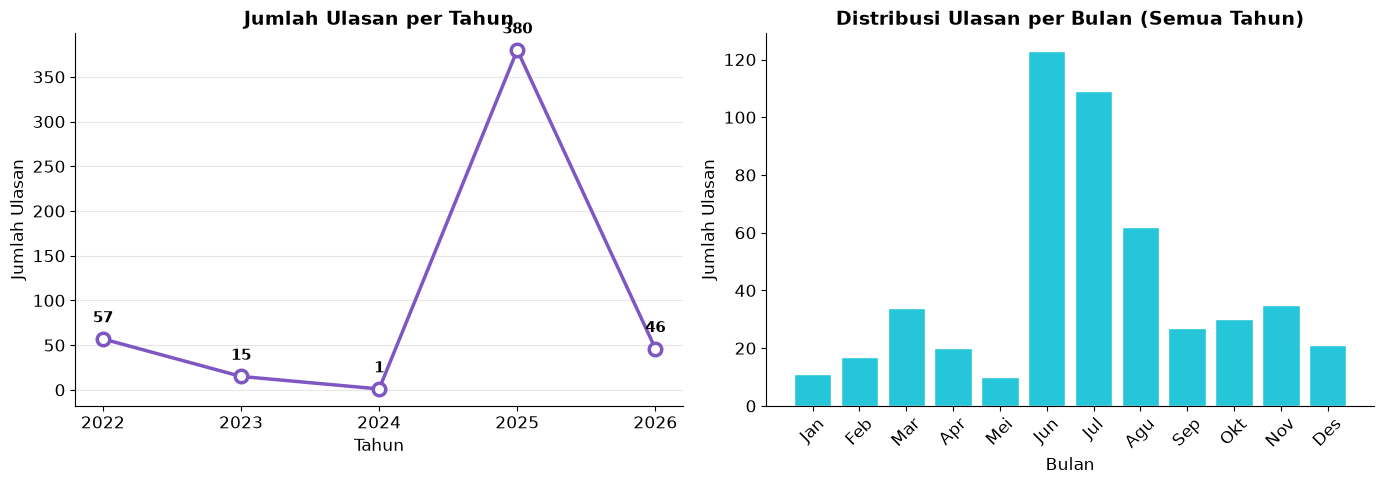

In [40]:
df['Waktu_dt'] = pd.to_datetime(df['Waktu'], errors='coerce')
df['Tahun']   = df['Waktu_dt'].dt.year
df['Bulan']   = df['Waktu_dt'].dt.month

tahun_count = df['Tahun'].value_counts().sort_index().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tren per Tahun
axes[0].plot(tahun_count.index.astype(int), tahun_count.values,
             marker='o', markersize=9, linewidth=2.5, color='#7E57C2',
             markerfacecolor='white', markeredgewidth=2.5)
for x, y in zip(tahun_count.index.astype(int), tahun_count.values):
    axes[0].annotate(f'{int(y)}', (x, y), textcoords='offset points',
                     xytext=(0, 12), ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Jumlah Ulasan per Tahun', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tahun')
axes[0].set_ylabel('Jumlah Ulasan')
axes[0].grid(axis='y', alpha=0.3)
axes[0].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Tren per Bulan (semua tahun)
bulan_count = df['Bulan'].value_counts().sort_index().dropna()
bulan_names = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']
axes[1].bar(bulan_count.index.astype(int), bulan_count.values,
            color='#26C6DA', edgecolor='white', linewidth=1)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(bulan_names, rotation=45)
axes[1].set_title('Distribusi Ulasan per Bulan (Semua Tahun)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Bulan')
axes[1].set_ylabel('Jumlah Ulasan')

plt.tight_layout()
plt.show()

### Frekuensi Kata Paling Sering Muncul

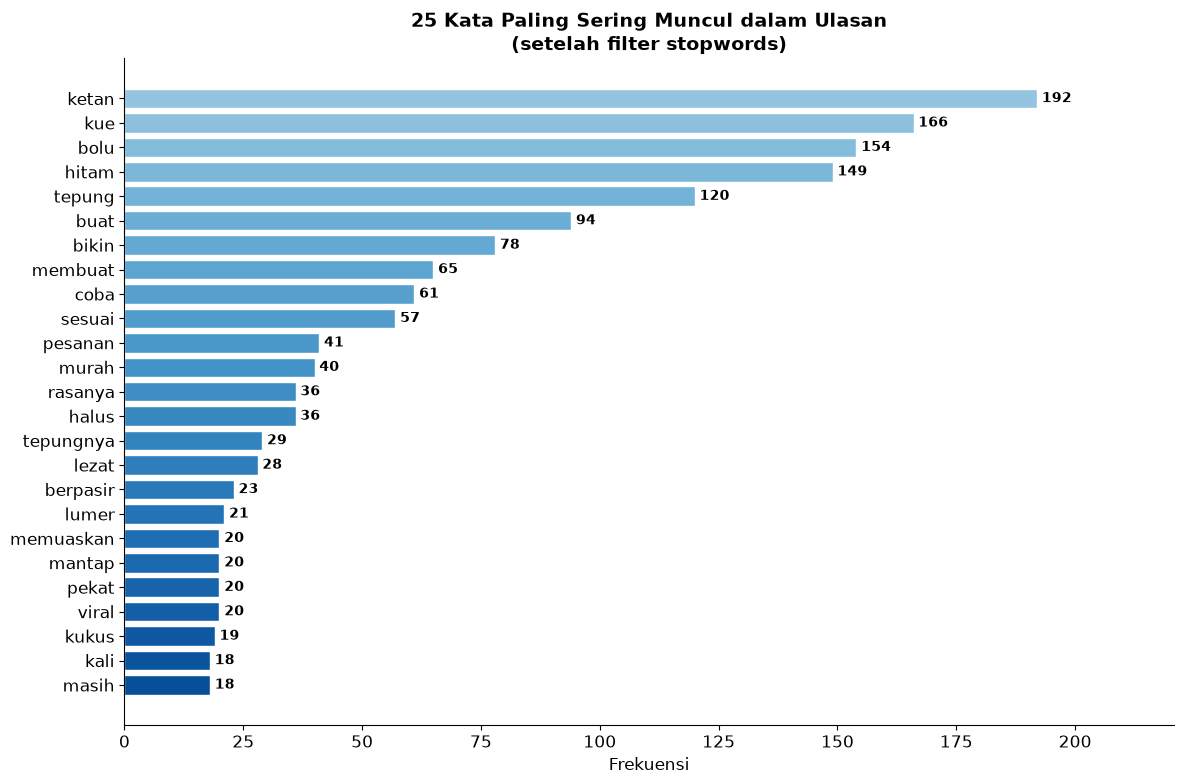

Kata kunci dominan yang ditemukan:
   1. ketan           → 192 kali
   2. kue             → 166 kali
   3. bolu            → 154 kali
   4. hitam           → 149 kali
   5. tepung          → 120 kali
   6. buat            → 94 kali
   7. bikin           → 78 kali
   8. membuat         → 65 kali
   9. coba            → 61 kali
  10. sesuai          → 57 kali


In [42]:
STOPWORDS = {
    'yang','dan','di','ke','dari','dengan','ini','itu','tidak','juga',
    'untuk','ya','saya','aku','kak','si','sudah','sdh','ada','bisa',
    'jadi','nya','ga','gak','tapi','tp','paket','sampai','seller',
    'udah','kalo','kalau','aja','deh','lagi','lah','sih','yg',
    'terimakasih','terima','kasih','makasih','semoga','lebih','banget',
    'bgt','sangat','alhamdulillah','packing','pengiriman','cepat','aman',
    'barang','produk','harga','bagus','baik','ok','oke','kakak','mau',
    'baru','next','order','beli','kualitas','cocok','jenis','kegunaan',
    'tekstur','rasa','rasakan','rapi','pas','dr','dg','bs','dlm',
    'lembut','enak','shopee','pake','pakai','km','kita','pun','blm',
    'belum','dicoba','smoga','hasilnya','dibikin','thanks','toko',
    'seller','kurir','pengiriman','packag','bubble','wrap'
}

all_text = ' '.join(df['Ulasan Text'].dropna().astype(str))
words = re.findall(r'\b[a-zA-Z]{3,}\b', all_text.lower())
filtered = [w for w in words if w not in STOPWORDS]
word_freq = Counter(filtered).most_common(25)

words_plot  = [w[0] for w in word_freq]
counts_plot = [w[1] for w in word_freq]

fig, ax = plt.subplots(figsize=(12, 8))
cmap = plt.colormaps['Blues']
bar_colors_word = [cmap(0.4 + 0.5 * i / len(words_plot)) for i in range(len(words_plot))]
bars = ax.barh(words_plot[::-1], counts_plot[::-1],
               color=bar_colors_word[::-1], edgecolor='white')
for bar, val in zip(bars, counts_plot[::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2.,
            f'{val}', va='center', fontsize=10, fontweight='bold')
ax.set_title('25 Kata Paling Sering Muncul dalam Ulasan\n(setelah filter stopwords)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Frekuensi')
ax.set_xlim(0, max(counts_plot) * 1.15)
plt.tight_layout()
plt.show()

print('Kata kunci dominan yang ditemukan:')
for i, (w, c) in enumerate(word_freq[:10], 1):
    print(f'  {i:2}. {w:<15} → {c} kali')

---
## 💾 7. Simpan Hasil Ringkasan ke CSV

In [44]:
# Simpan dataframe dengan kolom tambahan (panjang_teks, has_noise, Tahun, Bulan)
# untuk referensi di tahap Data Preparation
df_summary = df[['No','Username','Rating','Waktu','Ulasan Text','Variasi',
                 'panjang_teks','has_noise','Tahun','Bulan']].copy()
df_summary.to_csv('output_eda/ulasan_with_eda_flags.csv', index=False)
print('File ringkasan disimpan ke: output_eda/ulasan_with_eda_flags.csv')
print(f'   Total baris: {len(df_summary)}')
df_summary.head()

File ringkasan disimpan ke: output_eda/ulasan_with_eda_flags.csv
   Total baris: 499


,No,Username,Rating,Waktu,Ulasan Text,Variasi,panjang_teks,has_noise,Tahun,Bulan
0,1,t*****a,5,2022-08-28 16:48,Kualitas: bagus Cocok Untuk: boluu Nyampenya c...,-,236,False,2022,8
1,2,t*****9,5,2022-03-17 19:32,Jenis: tepung ketan hitam Harga: murah Kualita...,-,248,False,2022,3
2,3,a*****2,5,2025-07-07 20:01,Rasa: enak Tekstur: normal seperti tepung keta...,-,257,False,2025,7
3,4,nienieng,5,2025-06-06 19:08,Rasa: enak dibuat bolu Kegunaan: buat bolu ket...,-,259,False,2025,6
4,5,Langganan,5,2022-02-05 10:19,Jenis: tepung ketan hitam Harga: murah Kualita...,-,182,False,2022,2
